In [1]:
from pathlib import Path

import sys
# Add src to path for importing local modules
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from trompy import save_figure_atomic

from src.outlier_filter import robust_tail_filter_log_area
from src.add_extra_columns import add_extra_columns

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["font.size"] = 8
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams['savefig.transparent'] = True

SAVEFIGS = True

In [2]:
DATAFOLDER = Path("./data")
METAFILE = Path("./data/fenestrations_metafile.xlsx")
FIGSFOLDER = Path("./figs/paper1/panels")

# Ensure output folder exists for direct saves.
FIGSFOLDER.mkdir(parents=True, exist_ok=True)

# save_figure_atomic stages files under _tmp/<relative output path>;
# ensure that staging path exists when using relative figure folders.
(Path.cwd() / "_tmp" / FIGSFOLDER).mkdir(parents=True, exist_ok=True)

data = pd.read_pickle(DATAFOLDER / "roi_data.pickle")

# Extract the DataFrames
rois_df = data['rois']
summary_df = data['summary']

# load metafile
metadata = pd.read_excel(METAFILE)

print("ROI Data Statistics")
print("=" * 50)
print(f"\nROIs DataFrame:")
print(f"  Rows: {len(rois_df)}")
print(f"  Columns: {len(rois_df.columns)}")
print(f"  Column names: {list(rois_df.columns)}")
print(f"\n  Memory usage: {rois_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n\nSummary DataFrame:")
print(f"  Rows: {len(summary_df)}")
print(f"  Columns: {len(summary_df.columns)}")
print(f"  Column names: {list(summary_df.columns)}")
print(f"\n  Memory usage: {summary_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 50)
print("\nFirst few rows of ROIs DataFrame:")
print(rois_df.head())

print("\n" + "=" * 50)
print("\nFirst few rows of Summary DataFrame:")
print(summary_df.head())

print("\n" + "=" * 50)
print("\nData types:")
print("\nROIs DataFrame:")
print(rois_df.dtypes)
print("\nSummary DataFrame:")
print(summary_df.dtypes)

ROI Data Statistics

ROIs DataFrame:
  Rows: 234865
  Columns: 33
  Column names: ['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count', 'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids', 'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg', 'cluster_is_convex', 'cluster_center_inside_polygon', 'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major', 'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean', 'major_axis_angle', 'major_axis_extent', 'minor_axis_extent', 'major_axis_length_px', 'minor_axis_length_px', 'step_major', 'step_minor', 'step_diag45', 'step_diag135', 'diameter_area', 'experiment', 'condition']

  Memory usage: 262.44 MB


Summary DataFrame:
  Rows: 548
  Columns: 20
  Column names: ['id', 'stub', 'mean_neighbor_count', 'mean_cluster_neighbor_distance_px', 'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2', 'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm', 'mean_diameter_major_nm', 'mean

In [3]:
def get_filtered_control_data(rois_df, summary_df):
    
    rois_df, _ = robust_tail_filter_log_area(rois_df)
    rois_df = rois_df.query("condition == 'control'").reset_index(drop=True)
    summary_df = summary_df.query("condition == 'control'").reset_index(drop=True)
    
    return rois_df, summary_df

rois_df, summary_df = get_filtered_control_data(rois_df, summary_df)

# Add extra derived columns once so downstream plotting cells can rely on them.
rois_df, summary_df = add_extra_columns(
    rois_df,
    summary_df,
    union_dir=Path("./union_masks"),
    images_path=None,
    add_union_area=True,
)

In [4]:
rois_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59139 entries, 0 to 59138
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              59139 non-null  object 
 1   stub                            59139 non-null  object 
 2   roi_id                          59139 non-null  int64  
 3   centroid_x                      59139 non-null  float64
 4   centroid_y                      59139 non-null  float64
 5   pixel_count                     59139 non-null  int64  
 6   pixel_size                      59139 non-null  float64
 7   area                            59139 non-null  float64
 8   cluster_neighbor_count          45026 non-null  float64
 9   cluster_neighbor_ids            45026 non-null  object 
 10  cluster_max_internal_angle_deg  45026 non-null  float64
 11  cluster_max_angular_gap_deg     45026 non-null  float64
 12  cluster_is_convex               45026 non-n

In [5]:
# setting plotting conventions

def init_diameter_panel():
    f, ax = plt.subplots(figsize=(1.5, 1.2),
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.95, "bottom": 0.37})
    
    return f, ax

circular_color      = "#E9B07A"  # muted apricot
elliptical_color    = "#87BFAE"  # soft seafoam
profile_deriv_color = "#6F9DD9"  # muted blue
profile_fwhm_color  = "#8B86CF"  # muted violet
profile_p2p_color   = "#5FA8C7"  # muted cyan

circularity_color = "#8E97A1"

major_color = "#2F6DB3"  # balanced cobalt blue
minor_color = "#C96B28"  # muted amber-orange
neighbor_color = "goldenrod"


# circularity_diam_color = "coral"
# elliptical_color = "lightcoral"
# diameter_color = "steelblue"
# circularity_color = "coral"


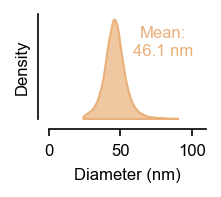

In [6]:
## Panel A: Diameter distribution (circular)

xlims = (0, 110)

f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.diameter_area,
            fill=True, ax=ax, color=circular_color, alpha=0.7,
            cut=0)

ax.set_xlim(xlims)
ax.set_xlabel("Diameter (nm)")

ax.set_yticks([])

ax.text(80, 0.04, f"Mean:\n{rois_df.diameter_area.mean():.1f} nm", ha="center", color=circular_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_circular")

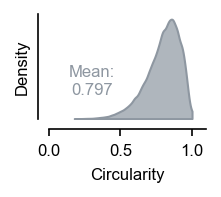

In [7]:
## Panel B: Circularity distribution

rois_df["circularity"] = rois_df.minor_axis_length_px / rois_df.major_axis_length_px


f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.circularity,
            fill=True, ax=ax, color=circularity_color, alpha=0.7,
            cut=0)
ax.set_xlabel("Circularity")
ax.set_xlim(0, 1.1)
ax.set_yticks([])

ax.text(0.3, 0.94, f"Mean:\n{rois_df.circularity.mean():.3f}", ha="center", color=circularity_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "circularity")

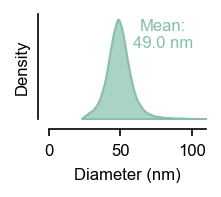

In [8]:
## Panel C: Diameter distribution (elliptical)

# Figure for diameter based on major/minor axis
# Calculate equivalent diameter in px
rois_df['elliptical_diameter'] = np.sqrt(rois_df.major_axis_length_px * rois_df.minor_axis_length_px) 

f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.elliptical_diameter,
            fill=True, ax=ax, color=elliptical_color, alpha=0.7,
            cut=0)

ax.set_xlabel("Diameter (nm)")
ax.set_xlim(xlims)
ax.set_yticks([])

ax.text(80, 0.04, f"Mean:\n{rois_df.elliptical_diameter.mean():.1f} nm", ha="center", color=elliptical_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_elliptical")


In [9]:
def get_spacing_factor(rois_df, row, axis):
    
    if axis == "major":
        return (rois_df
                .query("stub == @row.stub")
                .step_major_nm
                .mean()
                )
    elif axis == "minor":
        return (rois_df
                .query("stub == @row.stub")
                .step_minor_nm
                .mean()
                )
    else:
        raise ValueError("Axis must be 'major' or 'minor'")

# per-ROI nm per sample
rois_df["step_major_nm"] = rois_df["step_major"] * rois_df["pixel_size"]
rois_df["step_minor_nm"] = rois_df["step_minor"] * rois_df["pixel_size"]

In [10]:
rois_df.columns

Index(['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count',
       'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids',
       'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg',
       'cluster_is_convex', 'cluster_center_inside_polygon',
       'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major',
       'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean',
       'major_axis_angle', 'major_axis_extent', 'minor_axis_extent',
       'major_axis_length_px', 'minor_axis_length_px', 'step_major',
       'step_minor', 'step_diag45', 'step_diag135', 'diameter_area',
       'experiment', 'condition', 'robust_z_log_area', 'circularity',
       'step_major_nm', 'step_minor_nm', 'cluster_neighbor_distance_nm',
       'diameter_elliptical_nm', 'diameter_p2p_major_nm',
       'diameter_fwhm_major_nm', 'diameter_deriv_major_nm',
       'diameter_p2p_minor_nm', 'diameter_fwhm_minor_nm',
       'diameter_deriv_minor_nm', 'd

In [11]:
# Profile-based diameters are computed by add_extra_columns (applied to
# the per-stub averaged profiles) and live directly in summary_df.
print(
    summary_df[
        [
            "mean_diameter_p2p_major_nm", "mean_diameter_p2p_minor_nm", "mean_diameter_p2p_nm",
            "mean_diameter_fwhm_major_nm", "mean_diameter_fwhm_minor_nm", "mean_diameter_fwhm_nm",
            "mean_diameter_deriv_major_nm", "mean_diameter_deriv_minor_nm", "mean_diameter_deriv_nm",
        ]
    ].describe().round(1)
)

       mean_diameter_p2p_major_nm  mean_diameter_p2p_minor_nm  \
count                       137.0                       137.0   
mean                        122.5                       103.1   
std                          11.2                        14.2   
min                          99.6                        66.3   
25%                         113.8                        93.4   
50%                         121.5                       101.2   
75%                         130.0                       111.7   
max                         157.9                       148.6   

       mean_diameter_p2p_nm  mean_diameter_fwhm_major_nm  \
count                 137.0                        137.0   
mean                  112.2                         58.2   
std                    11.1                          7.1   
min                    86.5                         24.8   
25%                   103.9                         57.3   
50%                   111.3                         59

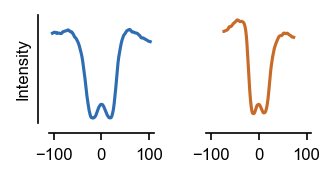

In [12]:
# prep data for profiles plot
row = summary_df.iloc[0]

f, ax = plt.subplots(figsize=(2.5, 1.2), ncols=2, sharey=True,
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.95, "bottom": 0.35,
                                      "wspace": 0.5})

major_profile = row.mean_profile_major_smpls
n = len(major_profile)
x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "major")

ax[0].plot(x_nm, major_profile, color=major_color)
ax[0].set_ylabel("Intensity")
ax[0].set_yticks([])

sns.despine(ax=ax[0], offset=5)

minor_profile = row.mean_profile_minor_smpls
n = len(minor_profile)
x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "minor")

ax[1].plot(x_nm, minor_profile, color=minor_color)

for axis in ax:
    axis.set_xlim(-110, 110)
    
sns.despine(ax=ax[1], offset=5, left=True)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "profiles")

In [13]:
[c for c in summary_df.columns if "diameter" in c]

['mean_diameter_area_nm',
 'mean_diameter_major_nm',
 'mean_diameter_minor_nm',
 'mean_diameter_four_axis_nm',
 'mean_diameter_p2p_major_nm',
 'mean_diameter_p2p_minor_nm',
 'mean_diameter_p2p_nm',
 'mean_diameter_fwhm_major_nm',
 'mean_diameter_fwhm_minor_nm',
 'mean_diameter_fwhm_nm',
 'mean_diameter_deriv_major_nm',
 'mean_diameter_deriv_minor_nm',
 'mean_diameter_deriv_nm']

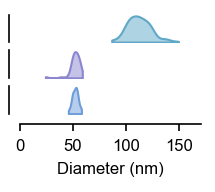

In [14]:
f, ax = plt.subplots(
    3, 1,
    figsize=(1.8, 1.2),
    # sharex=True,
    gridspec_kw={"left": 0.28, "right": 0.95, "top": 0.95, "bottom": 0.4, "hspace": 0.3}
)

kde_specs = [
    ("mean_diameter_p2p_nm", "P2P", profile_p2p_color),
    ("mean_diameter_fwhm_nm", "FWHM", profile_fwhm_color),
    ("mean_diameter_deriv_nm", "Derivative", profile_deriv_color),
]

for i, (col, label, color) in enumerate(kde_specs):
    vals = summary_df[col].dropna()
    if len(vals) > 1:
        sns.kdeplot(data=vals, fill=True, ax=ax[i], color=color, alpha=0.5, cut=0)

    ax[i].set_xlim(xlims)
    ax[i].set_yticks([])
    # ax[i].set_ylabel(label, rotation=0, ha="right", va="center", labelpad=12)
    ax[i].set_ylabel("")
    
    if i < 2:
        ax[i].set_xlabel("")

    sns.despine(ax=ax[i], offset=5)

xlims = (0, 170)

for axis in ax[:2]:
    sns.despine(ax=axis, bottom=True)
    axis.set_xticks([])
    axis.set_xlim(xlims)

ax[-1].set_xlabel("Diameter (nm)")
ax[-1].set_xticks([0, 50, 100, 150])
ax[-1].set_xlim(xlims)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_profiles")

In [15]:
summary_df[["mean_diameter_p2p_nm", "mean_diameter_fwhm_nm", "mean_diameter_deriv_nm"]]

,mean_diameter_p2p_nm,mean_diameter_fwhm_nm,mean_diameter_deriv_nm
0,111.479302,54.906506,53.218370
1,113.782318,55.555528,52.861228
2,137.742839,54.075576,48.034106
3,94.325198,47.782192,46.549051
4,123.353118,55.172855,53.116643
...,...,...,...
132,117.326304,51.146078,48.419387
133,119.990241,50.202396,50.559713
134,135.644676,56.238412,50.559587
135,108.043153,53.515903,50.107104


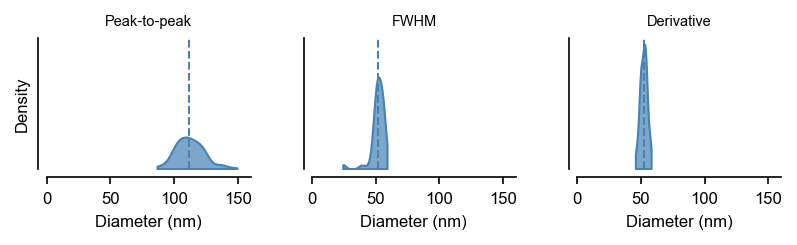

In [16]:
methods = {
    "mean_diameter_p2p_nm":  "Peak-to-peak",
    "mean_diameter_fwhm_nm": "FWHM",
    "mean_diameter_deriv_nm": "Derivative",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(5.5, 1.5),
    sharey=True,
    gridspec_kw={"left": 0.08, "right": 0.97, "top": 0.88,
                 "bottom": 0.3, "wspace": 0.3},
)

xlims = (0, 160)

for ax, (col, label) in zip(axes, methods.items()):
    vals = summary_df[col].dropna()
    if len(vals) > 1:
        sns.kdeplot(vals, ax=ax, fill=True, color="steelblue", alpha=0.7, cut=0)
    ax.axvline(vals.median(), color="steelblue", lw=1, ls="--")
    ax.set_xlim(xlims)
    ax.set_yticks([])
    ax.set_title(label, fontsize=7)
    ax.set_xlabel("Diameter (nm)")
    sns.despine(ax=ax, offset=4)

if SAVEFIGS:
    save_figure_atomic(fig, FIGSFOLDER / "diameter_profile_methods")

In [22]:
rois_df.columns

Index(['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count',
       'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids',
       'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg',
       'cluster_is_convex', 'cluster_center_inside_polygon',
       'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major',
       'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean',
       'major_axis_angle', 'major_axis_extent', 'minor_axis_extent',
       'major_axis_length_px', 'minor_axis_length_px', 'step_major',
       'step_minor', 'step_diag45', 'step_diag135', 'diameter_area',
       'experiment', 'condition', 'robust_z_log_area', 'circularity',
       'step_major_nm', 'step_minor_nm', 'cluster_neighbor_distance_nm',
       'diameter_elliptical_nm', 'diameter_p2p_major_nm',
       'diameter_fwhm_major_nm', 'diameter_deriv_major_nm',
       'diameter_p2p_minor_nm', 'diameter_fwhm_minor_nm',
       'diameter_deriv_minor_nm', 'd

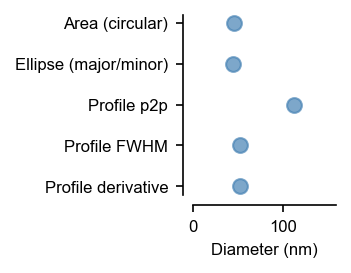

In [17]:
# Mean diameter comparing five measurement methods

# ROI-level elliptical diameter in nm from raw ROI extents (not profile path length)
major_diameter_nm = 2.0 * rois_df["major_axis_extent"] * rois_df["pixel_size"]
minor_diameter_nm = 2.0 * rois_df["minor_axis_extent"] * rois_df["pixel_size"]
rois_df["diameter_elliptical_nm"] = np.sqrt(major_diameter_nm * minor_diameter_nm)

diameter_boxplot_df = pd.concat(
    [
        pd.DataFrame({
            "method": "Area (circular)",
            "diameter_nm": rois_df["diameter_area"],
        }),
        pd.DataFrame({
            "method": "Ellipse (major/minor)",
            "diameter_nm": rois_df["diameter_elliptical_nm"],
        }),
        pd.DataFrame({
            "method": "Profile p2p",
            "diameter_nm": summary_df["mean_diameter_p2p_nm"],
        }),
        pd.DataFrame({
            "method": "Profile FWHM",
            "diameter_nm": summary_df["mean_diameter_fwhm_nm"],
        }),
        pd.DataFrame({
            "method": "Profile derivative",
            "diameter_nm": summary_df["mean_diameter_deriv_nm"],
        }),
    ],
    ignore_index=True,
).dropna(subset=["diameter_nm"])

method_order = [
    "Profile derivative",
    "Profile FWHM",
    "Profile p2p",
    "Ellipse (major/minor)",
    "Area (circular)",
]

# Compute mean for each method
mean_data = []
for method in method_order:
    data = diameter_boxplot_df[diameter_boxplot_df["method"] == method]["diameter_nm"].values
    mean = np.mean(data)
    mean_data.append({"method": method, "mean": mean})

mean_df = pd.DataFrame(mean_data)

f, ax = plt.subplots(
    figsize=(1.8, 1.5),
    gridspec_kw={"left": 0.45, "right": 0.98, "top": 0.95, "bottom": 0.15}
)

# Plot mean markers only
y_pos = np.arange(len(method_order))
ax.scatter(
    mean_df["mean"],
    y_pos,
    color="steelblue",
    s=50,
    alpha=0.7,
    zorder=3,
)

ax.set_yticks(y_pos)
ax.set_yticklabels(method_order)
ax.set_xlabel("Diameter (nm)")
ax.set_xlim(0, 160)

sns.despine(ax=ax, offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_boxplot_5methods")

C:\Users\jmc010\AppData\Local\Temp\ipykernel_28280\1950853575.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axis.axvspan(-row[diam_col]/2, row[diam_col]/2, color=diam_color, alpha=0.3, edgecolor="none", linewidth=0)
C:\Users\jmc010\AppData\Local\Temp\ipykernel_28280\1950853575.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axis.axvspan(-row[diam_col]/2, row[diam_col]/2, color=diam_color, alpha=0.3, edgecolor="none", linewidth=0)
C:\Users\jmc010\AppData\Local\Temp\ipykernel_28280\1950853575.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axis.axvspan(-row[diam_col]/2, row[diam_col]/2, color=diam_color, alpha=0.3, edgecolor="none", linewidth=0)
C:\Users\jmc010\AppData\Local\Temp\ipykernel_28280\1950853575.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axis.axvspan

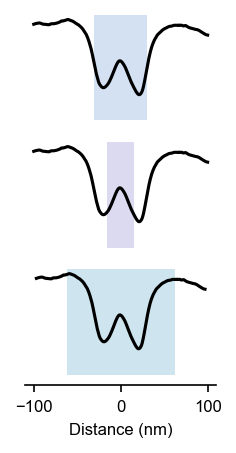

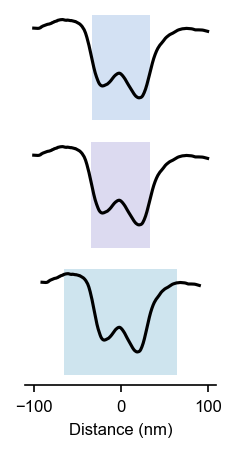

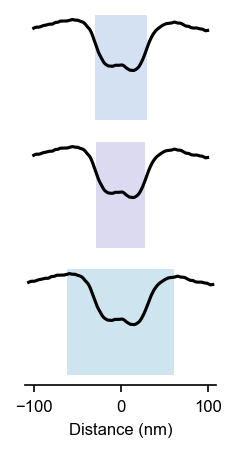

In [18]:
# supplemental - showing different diameter from profile measurements

def init_profile_fig():
    f, ax = plt.subplots(nrows=3, figsize=(1.5, 3),
                         gridspec_kw={"left": 0.10, "right": 0.95, "top": 0.95, "bottom": 0.15})
    
    return f, ax

rows_to_use = [0, 1, 2]

rows_from_df = summary_df.iloc[rows_to_use, :]

diameter_columns = ["mean_diameter_deriv_major_nm", "mean_diameter_fwhm_major_nm", "mean_diameter_p2p_major_nm"]
diameter_colors = [profile_deriv_color, profile_fwhm_color, profile_p2p_color]

def make_diameter_profile_plot(row):
    f, ax = init_profile_fig()

    for diam_col, diam_color, axis in zip(diameter_columns, diameter_colors, ax):
        major_profile = row.mean_profile_major_smpls
        n = len(major_profile)
        x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "major")

        axis.plot(x_nm, major_profile, color="k")
        # ax[0].set_ylabel("Intensity")
        axis.set_yticks([])
        axis.set_xticks([])
        axis.set_ylim(-2, 1.05 * major_profile.max())
        
        # set up fill_betweens
        axis.axvspan(-row[diam_col]/2, row[diam_col]/2, color=diam_color, alpha=0.3, edgecolor="none", linewidth=0)
        
        sns.despine(ax=axis, left=True, bottom=True, offset=5)

    sns.despine(ax=ax[-1], left=True, bottom=False, offset=5)
    ax[-1].set_xlim(-110, 110)
    ax[-1].set_xticks([-100, 0, 100])
    ax[-1].set_xlabel("Distance (nm)")
    
    return f, ax

rows_for_examples = {"1": 7, "2": 12, "3": 24}

for key, val in rows_for_examples.items():

    row = summary_df.iloc[val]
    f, ax = make_diameter_profile_plot(row)

    if SAVEFIGS:
        save_figure_atomic(f, FIGSFOLDER / f"diameter_profile_methods_example_{key}")


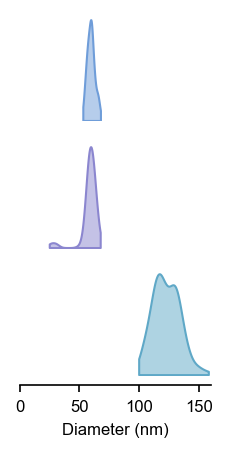

In [19]:
f, ax = init_profile_fig()

for diam_col, diam_color, axis in zip(diameter_columns, diameter_colors, ax):
    
    sns.kdeplot(
        data=summary_df[diam_col].dropna(),
        fill=True,
        ax=axis,
        color=diam_color,
        alpha=0.5,
        cut=0
    )
    
    axis.set_yticks([])
    axis.set_xticks([])
    axis.set_ylabel("")
    axis.set_xlabel("")
    axis.set_xlim(0, 160)
    
    sns.despine(ax=axis, left=True, bottom=True, offset=5)
    
sns.despine(ax=ax[-1], left=True, bottom=False, offset=5)
ax[-1].set_xlim(0, 160)
ax[-1].set_xticks([0, 50, 100, 150])
ax[-1].set_xlabel("Diameter (nm)")

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_profile_methods_kde")
    
    

In [20]:
ax[0].axvspan?

Signature: ax[0].axvspan(xmin, xmax, ymin=0, ymax=1, **kwargs)
Docstring:
Add a vertical span (rectangle) across the Axes.

The rectangle spans from *xmin* to *xmax* horizontally, and, by
default, the whole y-axis vertically.  The y-span can be set using
*ymin* (default: 0) and *ymax* (default: 1) which are in axis units;
e.g. ``ymin = 0.5`` always refers to the middle of the y-axis
regardless of the limits set by `~.Axes.set_ylim`.

Parameters
----------
xmin : float
    Lower x-coordinate of the span, in data units.
xmax : float
    Upper x-coordinate of the span, in data units.
ymin : float, default: 0
    Lower y-coordinate of the span, in y-axis units (0-1).
ymax : float, default: 1
    Upper y-coordinate of the span, in y-axis units (0-1).

Returns
-------
`~matplotlib.patches.Rectangle`
    Vertical span (rectangle) from (xmin, ymin) to (xmax, ymax).

Other Parameters
----------------
**kwargs : `~matplotlib.patches.Rectangle` properties

Properties:
    agg_filter: a filter fun

In [21]:
summary_df.columns

Index(['id', 'stub', 'mean_neighbor_count',
       'mean_cluster_neighbor_distance_px',
       'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2',
       'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm',
       'mean_diameter_major_nm', 'mean_diameter_minor_nm',
       'mean_diameter_four_axis_nm', 'mean_profile_major_smpls',
       'mean_profile_minor_smpls', 'mean_four_axis_smpls', 'porosity_square',
       'porosity_hex', 'porosity_blend', 'blend_weight', 'experiment',
       'condition', 'mean_diameter_p2p_major_nm', 'mean_diameter_p2p_minor_nm',
       'mean_diameter_p2p_nm', 'mean_diameter_fwhm_major_nm',
       'mean_diameter_fwhm_minor_nm', 'mean_diameter_fwhm_nm',
       'mean_diameter_deriv_major_nm', 'mean_diameter_deriv_minor_nm',
       'mean_diameter_deriv_nm', 'cell_area_square_nm2', 'cell_area_hex_nm2',
       'cell_area_blend_nm2', 'density_lattice_square', 'density_lattice_hex',
       'density_lattice_blend', 'union_mask_area_um2', 'roi_count',
       'dens